In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# loading dataset

In [ ]:
df = pd.read_csv("train.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


# Understanding Data 

In [ ]:
# finding first 5 rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
# finding last 5 rows
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


# data cleaning

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [ ]:
# removing extra spaces between columns
df.columns = df.columns.str.strip()

In [ ]:
# finding missing values
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [ ]:
# finding duplicate rows
df.duplicated().sum()

np.int64(0)

In [ ]:
# understanding statistical data
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
#  filling missing values in Age column by median of column for more accuracy
df["Age"] = df["Age"].fillna(df["Age"].median())

In [ ]:
# filling missing values in Embarked column by mode because this column contains string data
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [ ]:
# dropping cabin column because more than 70% cabin is missing so dropping is better option
df = df.drop(["Cabin"],axis=1)

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    str    
dtypes: float64(2), int64(5), str(4)
memory usage: 76.7 KB


In [ ]:
# Now the data is cleaned and ready for analysis

In [ ]:
# saving this clean dataset
df.to_csv("train_clean.csv",index=False)

# Now Exploratory Data Analysis 

In [ ]:
df = pd.read_csv("train_clean.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C


# 1.Overall Passenger Survival rate 

In [ ]:
# people count
survived = df["Survived"].value_counts()
survived

Survived
0    549
1    342
Name: count, dtype: int64

In [ ]:
# rate(%)
survived_rate = df["Survived"].value_counts(normalize=True).mul(100).round(2)
survived_rate

Survived
0    61.62
1    38.38
Name: proportion, dtype: float64

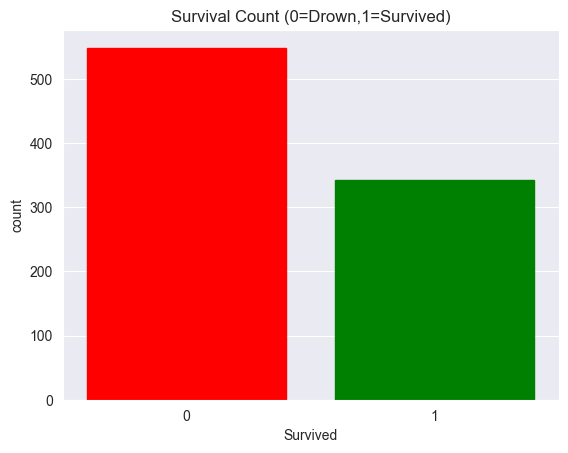

In [ ]:
sns.set_style("darkgrid")
ax = sns.countplot(x="Survived",data=df)
ax.patches[0].set_color("red")
ax.patches[1].set_color("green")
plt.title("Survival Count (0=Drown,1=Survived)")
plt.show()

# Insight: 

Out of (891) people ,549(61.6%) people died, 342(38.3%) people survived.

# 2.Male and Female Survival rate

In [ ]:
# count
male_female_survival = df[["Sex","Survived"]].value_counts()
male_female_survival

Sex     Survived
male    0           468
female  1           233
male    1           109
female  0            81
Name: count, dtype: int64

In [ ]:
# percentage(%)
gender = df.groupby("Sex")["Survived"].mean()*100
gender

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64

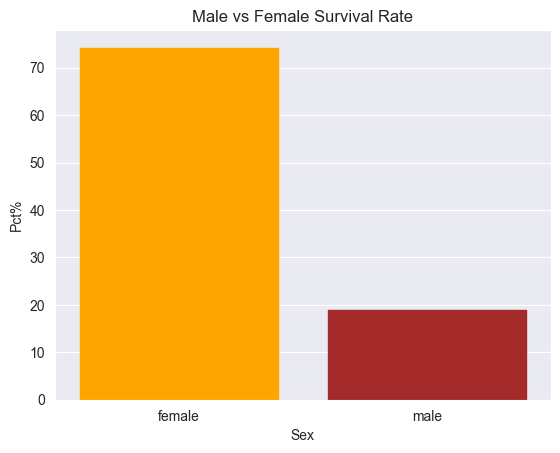

In [ ]:
ax = sns.barplot(x=gender.index,y=gender.values)
ax.patches[0].set_color("orange")
ax.patches[1].set_color("brown")
plt.title("Male vs Female Survival Rate")
plt.ylabel("Pct%")
plt.show()

# Insight:

More female (74.2%) survived than male (18.8%)

# 3.Pclass Survival Rate

In [ ]:
# passenger class survival rate%
passenger_rate = df.groupby("Pclass")["Survived"].mean().mul(100).round(2)
passenger_rate

Pclass
1    62.96
2    47.28
3    24.24
Name: Survived, dtype: float64

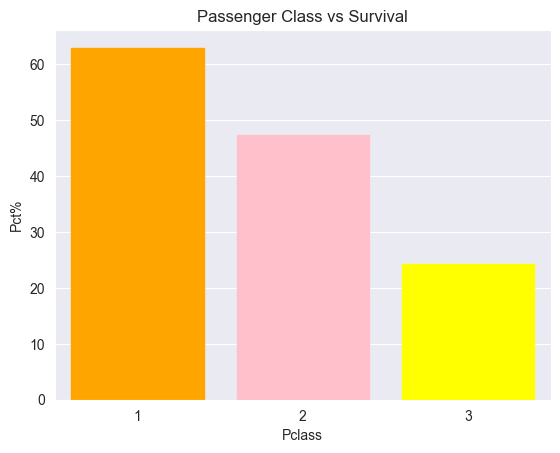

In [ ]:
ax = sns.barplot(x=passenger_rate.index,y=passenger_rate.values)
ax.patches[0].set_color("orange")
ax.patches[1].set_color("pink")
ax.patches[2].set_color("yellow")
plt.title("Passenger Class vs Survival")
plt.ylabel("Pct%")
plt.show()

# Insight:

1st class Passengers (62.9%) survived more than 2nd class Passengers (47.2%) and least survived 3rd class Passengers (24.2%).

# 4. Survival Rate by Age Group

In [ ]:
# creating age group based on age column
df["Age_group"] = pd.cut(df["Age"],bins=[0,10,18,40,60,80],labels=["Children","Teenagers","Adult","Old","Feeble"])

In [ ]:
age_group_rate = df.groupby("Age_group")["Survived"].mean().mul(100).round(2)
age_group_rate

Age_group
Children     59.38
Teenagers    42.67
Adult        36.05
Old          39.06
Feeble       22.73
Name: Survived, dtype: float64

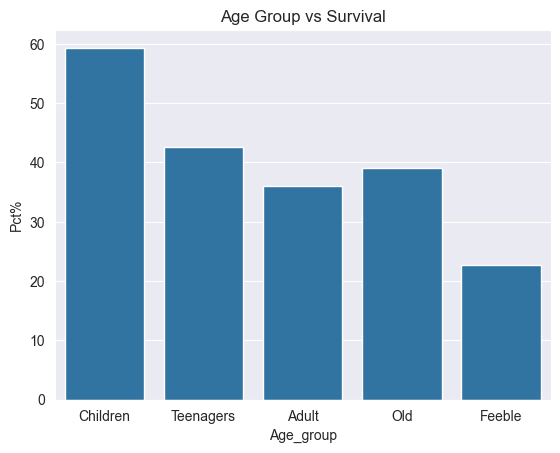

In [ ]:
sns.barplot(x=age_group_rate.index,y=age_group_rate.values)
plt.title("Age Group vs Survival")
plt.ylabel("Pct%")
plt.show()

# Insight:

Children Survived more with (59.3%) and least survived feeble age above 60 (22.7%).

# 5.Survival rate by Age

In [ ]:
# average age survival
age_survival = df.groupby("Survived")["Age"].mean()
age_survival

Survived
0    30.028233
1    28.291433
Name: Age, dtype: float64

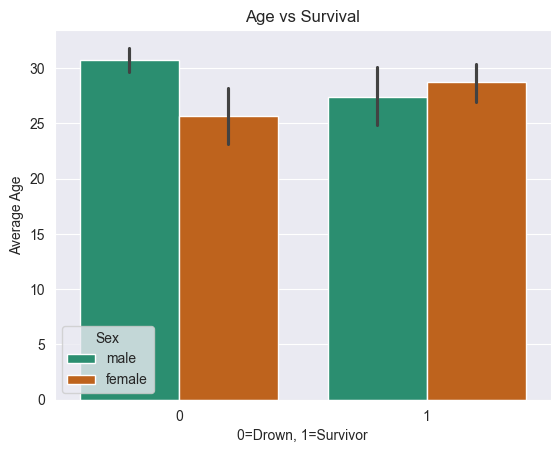

In [ ]:
sns.barplot(x="Survived",y="Age",data=df,hue="Sex",palette="Dark2")
plt.title("Age vs Survival")
plt.ylabel("Average Age")
plt.xlabel("0=Drown, 1=Survivor")
plt.show()

# Insight:

Passengers with average age (28.2 years) survived and the Passengers with average age (30 years) drowned.

# 6.Embarked Passenger Survival

In [ ]:
# passenger embarked survival rate
embarked = df.groupby("Embarked")["Survived"].mean().mul(100)
embarked

Embarked
C    55.357143
Q    38.961039
S    33.900929
Name: Survived, dtype: float64

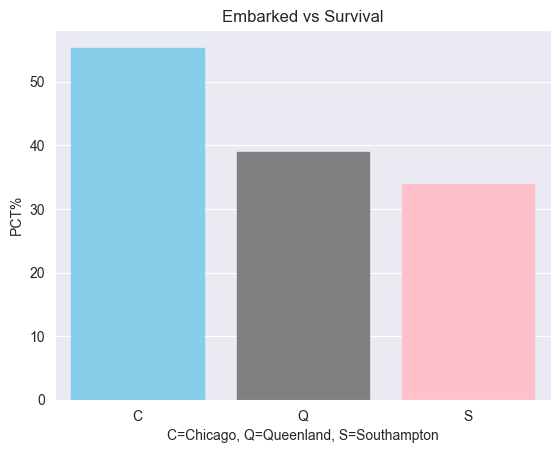

In [ ]:
ax = sns.barplot(x=embarked.index,y=embarked.values)
ax.patches[0].set_color("skyblue")
ax.patches[1].set_color("gray")
ax.patches[2].set_color("pink")
plt.title("Embarked vs Survival")
plt.ylabel("PCT%")
plt.xlabel("C=Chicago, Q=Queenland, S=Southampton")
plt.show()

# Insight:

Passengers embarked from Chicago has highest surival rate (55.3%) and lowest surival rate Southampton(33.9%) while Queenland has (38.9%) rate.

# 7.Fare Survival 

In [ ]:
# avergae fare
fare = df.groupby("Survived")["Fare"].mean()
fare

Survived
0    22.117887
1    48.395408
Name: Fare, dtype: float64

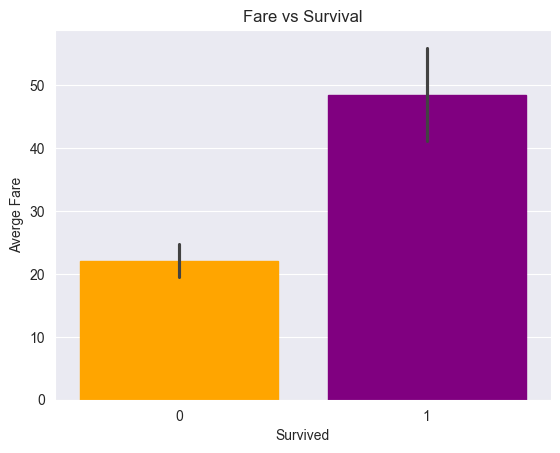

In [ ]:
ax = sns.barplot(x="Survived",y="Fare",data=df)
ax.patches[0].set_color("orange")
ax.patches[1].set_color("purple")
plt.title("Fare vs Survival")
plt.ylabel("Averge Fare")
plt.show()

# Insight:

Passengers who paid much fare on average (48.3) survived more than who paid on avergae (22.1)

# 8.FamilySize Survival

In [ ]:
# creating familysize column to check total family count
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
# survival rate by familysize
family = df.groupby("FamilySize")["Survived"].mean().mul(100)
family

FamilySize
1     30.353818
2     55.279503
3     57.843137
4     72.413793
5     20.000000
6     13.636364
7     33.333333
8      0.000000
11     0.000000
Name: Survived, dtype: float64

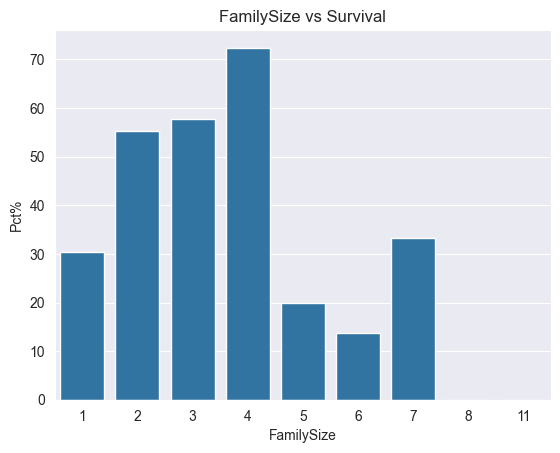

In [ ]:
sns.barplot(x=family.index,y=family.values)
plt.title("FamilySize vs Survival")
plt.ylabel("Pct%")
plt.show()

# Insight:

Passenger with family size 4 survived more (72.4%) than other families of size (1,2,3,5,6,7) while famil